In [1]:
import tensorflow as tf
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.preprocessing import load_and_preprocess_data
import matplotlib.pyplot as plt

2025-05-02 11:08:08.460177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746158888.478126   75802 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746158888.484322   75802 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-02 11:08:08.508922: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load and preprocess data
x_train, x_test, y_train, y_test = load_and_preprocess_data('../data/raw/weather.csv')
input_shape = x_train.shape

# One hot encode labels
y_train = tf.one_hot(indices=y_train, depth=2)
y_test = tf.one_hot(indices=y_test, depth=2)

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test))

I0000 00:00:1746158893.515684   75802 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
# Batch and shuffle dataset
BATCH_SIZE = 64
SHUFFLE_BUFFER_SIZE = 100
train_dataset = train_dataset.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

In [4]:
# Buffer dataset
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [5]:
# Build a Sequential model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])
    
# Model summary
model.summary()
    
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(), 
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=[tf.keras.metrics.CategoricalAccuracy(), tf.keras.metrics.F1Score(threshold=0.5)])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,170 (16.29 KB)

 Trainable params: 4,170 (16.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train the model
epochs = 10

# Check if GPU is available
if tf.config.list_physical_devices('GPU'):
    with tf.device('/GPU:0'):
        # Use GPU if available
        print("Training on GPU")
        history = model.fit(train_dataset, epochs=epochs, validation_data=test_dataset)
else:
    # Use CPU if GPU is not available
    print("Training on CPU")
    history = model.fit(train_dataset, epochs=epochs, validation_data=test_dataset)
    
# Save the model
model.save('rainfall_forecasting_ann_model.keras')

Training on GPU
Epoch 1/10


I0000 00:00:1746158895.616311   75947 service.cc:148] XLA service 0x7f181c006050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746158895.616360   75947 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2025-05-02 11:08:15.643543: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746158895.787176   75947 cuda_dnn.cc:529] Loaded cuDNN version 90300


  44/2061 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - categorical_accuracy: 0.5362 - f1_score: 0.5102 - loss: 0.6897  

I0000 00:00:1746158897.676732   75947 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2061/2061 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - categorical_accuracy: 0.7265 - f1_score: 0.7192 - loss: 0.5289 - val_categorical_accuracy: 0.7706 - val_f1_score: 0.7653 - val_loss: 0.4642
Epoch 2/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.7737 - f1_score: 0.7704 - loss: 0.4624 - val_categorical_accuracy: 0.7790 - val_f1_score: 0.7769 - val_loss: 0.4498
Epoch 3/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - categorical_accuracy: 0.7792 - f1_score: 0.7758 - loss: 0.4510 - val_categorical_accuracy: 0.7836 - val_f1_score: 0.7811 - val_loss: 0.4423
Epoch 4/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - categorical_accuracy: 0.7817 - f1_score: 0.7783 - loss: 0.4465 - val_categorical_accuracy: 0.7825 - val_f1_score: 0.7814 - val_loss: 0.4441
Epoch 5/10
2061/2061 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - categorical_accuracy: 0.7852 - f1_score: 0.7819 - loss: 0.4424 - val_categorical_accuracy: 0.7840 - val_f1_score: 0.7823 - val_loss: 0.4397
Epoch 6/10
2061/2061 ━━━━━━━━━

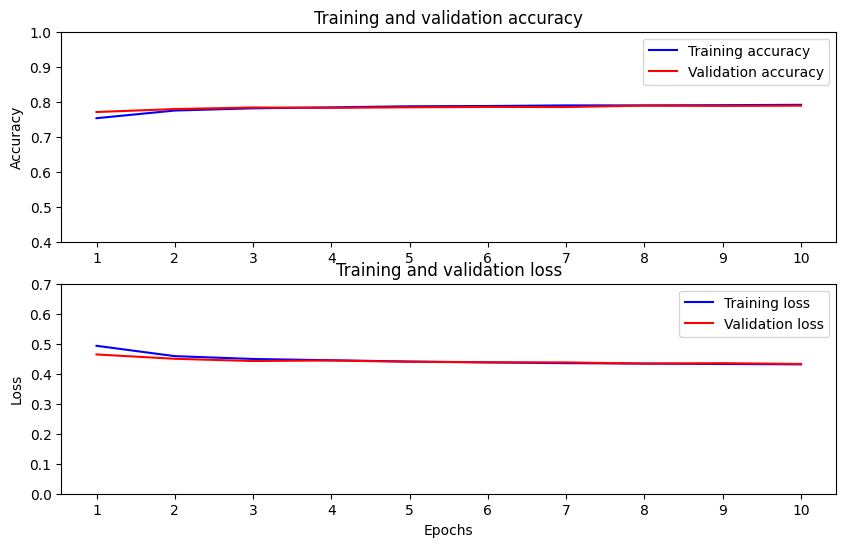

In [7]:
# Evaluate the model
accuracy = history.history['categorical_accuracy']
val_accuracy = history.history['val_categorical_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_count = range(1, epochs + 1)    

plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(epochs_count, accuracy, 'b', label='Training accuracy')
plt.plot(epochs_count, val_accuracy, 'r', label='Validation accuracy')
plt.ylabel('Accuracy')
plt.ylim(0.4, 1)
plt.xticks(epochs_count)
plt.title('Training and validation accuracy')
plt.legend()
    
plt.subplot(2, 1, 2)
plt.plot(epochs_count, loss, 'b', label='Training loss')
plt.plot(epochs_count, val_loss, 'r', label='Validation loss')
plt.ylabel('Loss')
plt.ylim(0, 0.7)
plt.xticks(epochs_count)
plt.xlabel('Epochs')
plt.title('Training and validation loss')
plt.legend()
plt.show()

In [8]:
history_f1 = history.history['f1_score']
history_val_f1 = history.history['val_f1_score']

f1_score = tf.math.reduce_mean(history_f1, 1).numpy().tolist() 
val_f1_score = tf.math.reduce_mean(history_val_f1, 1).numpy().tolist()  